# Cloud-Based Diabetes Prediction Pipeline Using PySpark MLlib

## Team Members
- Aniket Shirsat
- Carson Mohler
- David Ndungu
- Sahiti Somalraju

---

## Project Overview

This notebook implements a **PySpark + XGBoost/CatBoost** pipeline for diabetes prediction, designed for cloud computing environments.

### Key Features
- **Comprehensive feature analysis**: Correlation, Mutual Information, and Gain-based importance
- **Tuned models**: XGBoost and CatBoost with optimized hyperparameters from cross-validation
- **Interactive visualizations**: Plotly charts for feature interactions and risk analysis
- **Risk tier system**: Interpretable risk categories (None, Low, Moderate, High, Extreme)
- **Dash App Dashboard**: Interactive ML-powered risk assessment tool

### Pipeline Workflow

| Section | Description |
|---------|-------------|
| 1. Environment Setup | Install Java, PySpark, XGBoost, CatBoost, Dash |
| 2. Data Loading | Load BRFSS 2015 diabetes dataset |
| 3. Exploratory Data Analysis | Feature statistics and correlations |
| 4. Advanced Feature Analysis | Mutual Information, Gain importance |
| 5. Data Imbalance Analysis | Class distribution analysis |
| 6. Feature Selection | Top 10 features by importance |
| 7. Data Preparation | Stratified split, oversampling |
| 8. Model Training | Baseline and tuned XGBoost/CatBoost |
| 9. Model Evaluation | Class-specific metrics, confusion matrices |
| 10. Interactive Visualizations | Plotly charts for feature analysis |
| 11. Threshold Tuning & Risk Tiers | Optimize detection thresholds |
| 12. Dash App Dashboard | Interactive risk assessment |
| 13. Save Models & Summary | Export artifacts |

---
## 1. Environment Setup

Install and configure all dependencies.

In [ ]:
# 1A. GOOGLE COLAB SETUP - RUN THIS CELL FIRST!
import subprocess
import os
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Not running in Colab - skipping Colab-specific setup")

if IN_COLAB:
    print("\n" + "="*60)
    print("INSTALLING DEPENDENCIES FOR GOOGLE COLAB")
    print("="*60)

    print("\nStep 1/6: Installing Java (required for Spark)...")
    !apt-get update -qq
    !apt-get install -y openjdk-11-jdk-headless -qq

    print("\nStep 2/6: Setting environment variables...")
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
    os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

    print("\nStep 3/6: Installing PySpark...")
    !pip install -q pyspark==3.5.0 findspark

    print("\nStep 4/6: Installing XGBoost and CatBoost...")
    !pip install -q xgboost catboost

    print("\nStep 5/6: Installing visualization and Dash libraries...")
    !pip install -q matplotlib seaborn plotly "dash==3.2.0" dash-bootstrap-components jupyter-dash

    print("\nStep 6/6: Testing installations...")
    import findspark
    findspark.init()

    from pyspark.sql import SparkSession
    test_spark = SparkSession.builder.appName("Test").getOrCreate()
    print(f"   Spark version: {test_spark.version}")
    test_spark.stop()

    import xgboost
    print(f"   XGBoost version: {xgboost.__version__}")

    import catboost
    print(f"   CatBoost version: {catboost.__version__}")

    import dash
    print(f"   Dash version: {dash.__version__}")

    print("\n" + "="*60)
    print("SUCCESS! All dependencies installed.")
    print("="*60)
else:
    print("Skipping Colab setup. Proceed to next cells.")
    print("Make sure you have installed: pyspark, xgboost, catboost, dash, dash-bootstrap-components")

Running in Google Colab

INSTALLING DEPENDENCIES FOR GOOGLE COLAB

Step 1/6: Installing Java (required for Spark)...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.29+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.29+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/j

In [ ]:
# 1B. ENVIRONMENT DETECTION AND DIRECTORY SETUP
import sys
import os

def detect_environment():
    """Detect if running in Google Colab or IU JupyterHub"""
    try:
        import google.colab
        return 'colab'
    except ImportError:
        pass
    if os.path.exists('/home/students'):
        return 'iu_aspen'
    return 'local'

ENVIRONMENT = detect_environment()
print(f"Environment: {ENVIRONMENT.upper()}")

# Set up directories based on environment
if ENVIRONMENT == 'colab':
    DATA_DIR = '/content'
    MODELS_DIR = '/content/models'
    OUTPUTS_DIR = '/content/outputs'
elif ENVIRONMENT == 'iu_aspen':
    username = os.environ.get('USER', 'student')
    DATA_DIR = f'/home/students/{username}'
    MODELS_DIR = f'/home/students/{username}/models'
    OUTPUTS_DIR = f'/home/students/{username}/outputs'
else:
    DATA_DIR = '.'
    MODELS_DIR = './models'
    OUTPUTS_DIR = './outputs'

# Create directories
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")

Environment: COLAB
Data directory: /content
Models directory: /content/models
Outputs directory: /content/outputs


In [ ]:
# 1C. INITIALIZE SPARK AND ALL IMPORTS
try:
    import findspark
    findspark.init()
except:
    pass

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    DecisionTreeClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.mllib.evaluation import MulticlassMetrics, BinaryClassificationMetrics

# XGBoost and CatBoost
import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Standard libraries
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

# Create Spark session
spark = SparkSession.builder \
    .appName("DiabetesPrediction_Integrated") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")
print(f"XGBoost Version: {xgb.__version__}")
print(f"Spark Session: Active")

Spark Version: 3.5.0
XGBoost Version: 3.1.2
Spark Session: Active


---
## 2. Data Loading

Load the BRFSS 2015 diabetes dataset.

In [ ]:
# 2. DATA LOADING
print("LOADING DATASET")

# Download dataset if in Colab
if ENVIRONMENT == 'colab':
    import urllib.request

    kaggle_url = "https://raw.githubusercontent.com/npradascern/diabetes-dataset/main/diabetes_binary_health_indicators_BRFSS2015.csv"
    data_path = f"{DATA_DIR}/diabetes_data.csv"

    try:
        urllib.request.urlretrieve(kaggle_url, data_path)
        print(f"Downloaded BRFSS dataset to: {data_path}")
    except:
        print("Attempting to load from Google Drive or local storage...")
        data_path = f"{DATA_DIR}/diabetes_binary_health_indicators_BRFSS2015.csv"
else:
    data_path = f"{DATA_DIR}/diabetes_binary_health_indicators_BRFSS2015.csv"

# Load data with PySpark
df_spark = spark.read.csv(data_path, header=True, inferSchema=True)
df_spark = df_spark.cache()
total_records = df_spark.count()

# Also load with Pandas for sklearn models and analysis
df = df_spark.toPandas()

print(f"\nDataset loaded successfully!")
print(f"Total records: {total_records:,}")
print(f"Total features: {len(df.columns)}")
print(f"\nColumns: {list(df.columns)}")

LOADING DATASET
Attempting to load from Google Drive or local storage...

Dataset loaded successfully!
Total records: 253,680
Total features: 22

Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


---
## 3. Exploratory Data Analysis

In [ ]:
# 3. EXPLORATORY DATA ANALYSIS
print("EXPLORATORY DATA ANALYSIS")

print("\nDataset Schema:")
df_spark.printSchema()

print("\nSample Data (first 5 rows):")
df_spark.show(5, truncate=False)

print("\nBasic Statistics:")
df_spark.describe().show()

# List all original features (excluding target)
original_features = [c for c in df.columns if c != 'Diabetes_binary']
print(f"\nOriginal Features ({len(original_features)}):")
for i, feat in enumerate(original_features, 1):
    print(f"   {i:2d}. {feat}")

EXPLORATORY DATA ANALYSIS

Dataset Schema:
root
 |-- Diabetes_binary: double (nullable = true)
 |-- HighBP: double (nullable = true)
 |-- HighChol: double (nullable = true)
 |-- CholCheck: double (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smoker: double (nullable = true)
 |-- Stroke: double (nullable = true)
 |-- HeartDiseaseorAttack: double (nullable = true)
 |-- PhysActivity: double (nullable = true)
 |-- Fruits: double (nullable = true)
 |-- Veggies: double (nullable = true)
 |-- HvyAlcoholConsump: double (nullable = true)
 |-- AnyHealthcare: double (nullable = true)
 |-- NoDocbcCost: double (nullable = true)
 |-- GenHlth: double (nullable = true)
 |-- MentHlth: double (nullable = true)
 |-- PhysHlth: double (nullable = true)
 |-- DiffWalk: double (nullable = true)
 |-- Sex: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Education: double (nullable = true)
 |-- Income: double (nullable = true)


Sample Data (first 5 rows):
+---------------+------+---

---
## 4. Advanced Feature Analysis

Comprehensive feature analysis using multiple methods.

In [ ]:
# 4A. FEATURE TYPE CLASSIFICATION AND STATISTICS
print("ADVANCED FEATURE ANALYSIS")
print("="*80)

def classify_feature(series):
    """Classify feature as Binary, Categorical, or Continuous"""
    n_unique = series.nunique()
    if n_unique == 2:
        return 'Binary'
    elif n_unique <= 10:
        return 'Categorical'
    else:
        return 'Continuous'

# Prepare features and target
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Calculate mutual information
print("\nCalculating Mutual Information scores...")
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_dict = dict(zip(X.columns, mi_scores))
mi_dict['Diabetes_binary'] = None

# Create comprehensive feature summary
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Type': [classify_feature(df[col]) for col in df.columns],
    'Pearson': [df[col].corr(df['Diabetes_binary']) for col in df.columns],
    'Spearman': [df[col].corr(df['Diabetes_binary'], method='spearman') for col in df.columns],
    'Mutual Info': [mi_dict.get(col, None) for col in df.columns]
})

print("\nFeature Summary:")
print(feature_summary.to_string(index=False))

ADVANCED FEATURE ANALYSIS

Calculating Mutual Information scores...

Feature Summary:
             Feature  Unique Values        Type   Pearson  Spearman  Mutual Info
     Diabetes_binary              2      Binary  1.000000  1.000000          NaN
              HighBP              2      Binary  0.263129  0.263129     0.053140
            HighChol              2      Binary  0.200276  0.200276     0.040654
           CholCheck              2      Binary  0.064761  0.064761     0.048799
                 BMI             84  Continuous  0.216843  0.226314     0.030828
              Smoker              2      Binary  0.060789  0.060789     0.024667
              Stroke              2      Binary  0.105816  0.105816     0.004306
HeartDiseaseorAttack              2      Binary  0.177282  0.177282     0.014241
        PhysActivity              2      Binary -0.118133 -0.118133     0.052416
              Fruits              2      Binary -0.040779 -0.040779     0.042253
             Veggies   

In [ ]:
# 4B. BASELINE MODELS TO GET FEATURE IMPORTANCE BY GAIN
print("\nTraining baseline XGBoost to analyze feature importance by Gain...")

# Quick train/test split for feature analysis
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scale_pos = (y_train_temp == 0).sum() / (y_train_temp == 1).sum()

# Train baseline XGBoost
xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_baseline.fit(X_train_temp, y_train_temp)

# Get feature importance by gain
gain_dict = xgb_baseline.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': gain_dict.keys(),
    'Gain': gain_dict.values()
}).sort_values('Gain', ascending=False).reset_index(drop=True)
importance_df.index = importance_df.index + 1  # Start ranking at 1

print("\nFeature Ranking by XGBoost Gain:")
print(importance_df.head(15).to_string())


Training baseline XGBoost to analyze feature importance by Gain...

Feature Ranking by XGBoost Gain:
                 Feature        Gain
1                 HighBP  690.543884
2                GenHlth  171.775131
3               HighChol   90.535576
4                    Age   46.387966
5              CholCheck   43.929611
6                    BMI   37.475407
7      HvyAlcoholConsump   36.366360
8   HeartDiseaseorAttack   34.781586
9                    Sex   28.991316
10              DiffWalk   25.601074
11                Income   18.060209
12                Stroke   15.634434
13             Education   11.645278
14                Fruits   11.442997
15          PhysActivity   10.751622


---
## 5. Data Imbalance Analysis

In [ ]:
# 5. DATA IMBALANCE ANALYSIS
print("DATA IMBALANCE ANALYSIS")
print("="*60)

# Calculate class distribution
class_distribution = df_spark.groupBy("Diabetes_binary").agg(
    F.count("*").alias("count")
).orderBy("Diabetes_binary")

class_distribution = class_distribution.withColumn(
    "percentage",
    F.round(F.col("count") / total_records * 100, 2)
)

print("\nTarget Variable Distribution:")
class_distribution.show()

# Get counts for ratio calculation
class_counts = class_distribution.collect()
no_diabetes_count = class_counts[0]['count']
diabetes_count = class_counts[1]['count']
imbalance_ratio = no_diabetes_count / diabetes_count

print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"   No Diabetes (0): {no_diabetes_count:,} ({class_counts[0]['percentage']}%)")
print(f"   Diabetes (1): {diabetes_count:,} ({class_counts[1]['percentage']}%)")

print("\n" + "="*60)
print("SOLUTION: Using scale_pos_weight (XGBoost) + auto_class_weights (CatBoost)")
print("="*60)

DATA IMBALANCE ANALYSIS

Target Variable Distribution:
+---------------+------+----------+
|Diabetes_binary| count|percentage|
+---------------+------+----------+
|            0.0|218334|     86.07|
|            1.0| 35346|     13.93|
+---------------+------+----------+

Imbalance Ratio: 6.18:1
   No Diabetes (0): 218,334 (86.07%)
   Diabetes (1): 35,346 (13.93%)

SOLUTION: Using scale_pos_weight (XGBoost) + auto_class_weights (CatBoost)


---
## 6. Feature Selection

Select top 10 features based on gain importance and domain knowledge.

In [ ]:
# 6. FEATURE SELECTION - TOP 10 FEATURES
print("FEATURE SELECTION")
print("="*60)

# Top 10 features based on XGBoost Gain analysis (Income removed for privacy)
SELECTED_FEATURES = [
    'GenHlth',              # General Health (1-5 scale)
    'HighBP',               # High Blood Pressure (0/1)
    'BMI',                  # Body Mass Index
    'Age',                  # Age category (1-13)
    'HighChol',             # High Cholesterol (0/1)
    'CholCheck',            # Cholesterol check in past 5 years (0/1)
    'DiffWalk',             # Difficulty walking (0/1)
    'HeartDiseaseorAttack', # History of heart disease (0/1)
    'Sex',                  # Sex (0=Female, 1=Male)
    'HvyAlcoholConsump'     # Heavy alcohol consumption (0/1)
]

NUM_FEATURES = len(SELECTED_FEATURES)

print(f"\nSelected TOP {NUM_FEATURES} FEATURES (based on XGBoost Gain):")
print("-"*60)
for i, feat in enumerate(SELECTED_FEATURES, 1):
    gain = gain_dict.get(feat, 0)
    pearson = df[feat].corr(df['Diabetes_binary'])
    print(f"   {i:2d}. {feat:<25} Gain: {gain:>10.2f}  Pearson: {pearson:>+.4f}")

print("\n" + "-"*60)
print("WHY THESE 10 FEATURES?")
print("   - Top features by XGBoost gain importance")
print("   - Income removed for privacy considerations")
print("   - Clinically interpretable features")
print("   - XGBoost/CatBoost discover interactions automatically")
print("-"*60)

FEATURE SELECTION

Selected TOP 10 FEATURES (based on XGBoost Gain):
------------------------------------------------------------
    1. GenHlth                   Gain:     171.78  Pearson: +0.2936
    2. HighBP                    Gain:     690.54  Pearson: +0.2631
    3. BMI                       Gain:      37.48  Pearson: +0.2168
    4. Age                       Gain:      46.39  Pearson: +0.1774
    5. HighChol                  Gain:      90.54  Pearson: +0.2003
    6. CholCheck                 Gain:      43.93  Pearson: +0.0648
    7. DiffWalk                  Gain:      25.60  Pearson: +0.2183
    8. HeartDiseaseorAttack      Gain:      34.78  Pearson: +0.1773
    9. Sex                       Gain:      28.99  Pearson: +0.0314
   10. HvyAlcoholConsump         Gain:      36.37  Pearson: -0.0571

------------------------------------------------------------
WHY THESE 10 FEATURES?
   - Top features by XGBoost gain importance
   - Income removed for privacy considerations
   - Clinical

---
## 7. Data Preparation

Prepare data with stratified split for fair evaluation.

In [ ]:
# 7. DATA PREPARATION
print("DATA PREPARATION")
print("="*60)

# Prepare features and target with selected features
X_selected = df[SELECTED_FEATURES]
y = df['Diabetes_binary']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nTraining class distribution:")
print(f"   No Diabetes: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   Diabetes: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

DATA PREPARATION

Training set: 202,944 samples
Test set: 50,736 samples

Training class distribution:
   No Diabetes: 174,667 (86.1%)
   Diabetes: 28,277 (13.9%)

scale_pos_weight: 6.18


---
## 8. Model Training

Train baseline and tuned XGBoost/CatBoost models.

In [ ]:
# 8A. TRAIN BASELINE MODELS
print("MODEL TRAINING")
print("="*70)

print("\n[1/4] Training Baseline XGBoost...")
xgb_baseline_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_baseline_model.fit(X_train, y_train)
print("   ✓ Baseline XGBoost trained!")

print("\n[2/4] Training Baseline CatBoost...")
cat_baseline_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)
cat_baseline_model.fit(X_train, y_train)
print("   ✓ Baseline CatBoost trained!")

MODEL TRAINING

[1/4] Training Baseline XGBoost...
   ✓ Baseline XGBoost trained!

[2/4] Training Baseline CatBoost...
   ✓ Baseline CatBoost trained!


In [ ]:
# 8B. TRAIN TUNED MODELS (Best hyperparameters from RandomizedSearchCV)
print("\n[3/4] Training Tuned XGBoost (optimized hyperparameters)...")
xgb_tuned_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    # Tuned hyperparameters from RandomizedSearchCV
    subsample=0.9,
    reg_lambda=10,
    reg_alpha=1,
    n_estimators=500,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.9
)
xgb_tuned_model.fit(X_train, y_train)
print("   ✓ Tuned XGBoost trained!")

print("\n[4/4] Training Tuned CatBoost (optimized hyperparameters)...")
cat_tuned_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0,
    # Tuned hyperparameters from RandomizedSearchCV
    random_strength=1,
    learning_rate=0.15,
    l2_leaf_reg=3,
    iterations=300,
    depth=3,
    bagging_temperature=0
)
cat_tuned_model.fit(X_train, y_train)
print("   ✓ Tuned CatBoost trained!")

print("\n" + "="*70)
print("All 4 models trained!")
print("="*70)


[3/4] Training Tuned XGBoost (optimized hyperparameters)...
   ✓ Tuned XGBoost trained!

[4/4] Training Tuned CatBoost (optimized hyperparameters)...
   ✓ Tuned CatBoost trained!

All 4 models trained!


---
## 9. Model Evaluation

Evaluate models with class-specific metrics for diabetes detection.

In [15]:
# 9A. EVALUATION FUNCTION
def evaluate_model(name, model, X_test, y_test):
    """Evaluate model and return metrics dictionary"""
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Recall': recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Accuracy': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC': roc_auc_score(y_test, prob),
        'y_pred': pred,
        'y_prob': prob
    }

# Evaluate all models
print("MODEL EVALUATION")
print("="*90)
print("IMPORTANT: Reporting DIABETES CLASS (1) specific metrics")
print("="*90)

results = {}
results['XGBoost Baseline'] = evaluate_model('XGBoost Baseline', xgb_baseline_model, X_test, y_test)
results['CatBoost Baseline'] = evaluate_model('CatBoost Baseline', cat_baseline_model, X_test, y_test)
results['XGBoost Tuned'] = evaluate_model('XGBoost Tuned', xgb_tuned_model, X_test, y_test)
results['CatBoost Tuned'] = evaluate_model('CatBoost Tuned', cat_tuned_model, X_test, y_test)

# Create results DataFrame
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
    for r in results.values()
]).sort_values('Recall', ascending=False)

print("\nResults (sorted by Recall):")
print(results_df.to_string(index=False))

MODEL EVALUATION
IMPORTANT: Reporting DIABETES CLASS (1) specific metrics

Results (sorted by Recall):
            Model   Recall  Precision  Accuracy       F1      AUC
    XGBoost Tuned 0.796718   0.302959  0.716276 0.438988 0.825462
   CatBoost Tuned 0.795303   0.304155  0.717971 0.440027 0.825360
 XGBoost Baseline 0.786108   0.303562  0.718918 0.437990 0.821209
CatBoost Baseline 0.782289   0.303663  0.719726 0.437500 0.821372



CONFUSION MATRICES


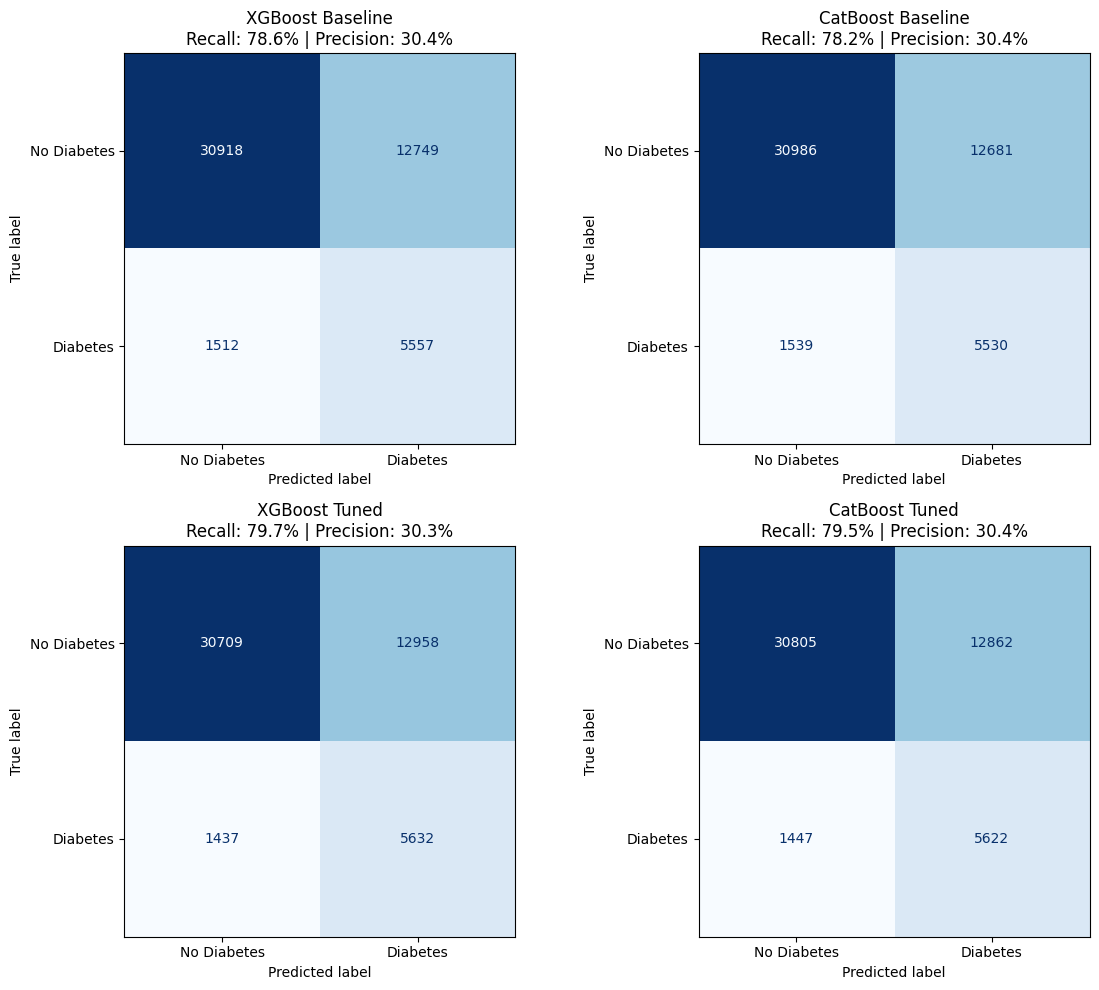


✓ Confusion matrices saved to: /content/outputs/confusion_matrices.png


In [16]:
# 9B. CONFUSION MATRICES VISUALIZATION
print("\nCONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = [
    ('XGBoost Baseline', xgb_baseline_model),
    ('CatBoost Baseline', cat_baseline_model),
    ('XGBoost Tuned', xgb_tuned_model),
    ('CatBoost Tuned', cat_tuned_model)
]

for ax, (name, model) in zip(axes.flat, models_list):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    recall = cm[1,1] / (cm[1,0] + cm[1,1])
    precision = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
    ax.set_title(f'{name}\nRecall: {recall:.1%} | Precision: {precision:.1%}')

plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrices saved to: {OUTPUTS_DIR}/confusion_matrices.png")

In [17]:
# 9C. FEATURE IMPORTANCE FROM TUNED MODELS
print("\nFEATURE IMPORTANCE (Tuned XGBoost)")
print("="*60)

# Get feature importance by gain from tuned model
gain_dict_tuned = xgb_tuned_model.get_booster().get_score(importance_type='gain')
importance_tuned_df = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Weight': xgb_tuned_model.feature_importances_
})
importance_tuned_df['Gain'] = importance_tuned_df['Feature'].map(gain_dict_tuned).fillna(0)
importance_tuned_df = importance_tuned_df.sort_values('Gain', ascending=False)

print("\nFeature Importance (XGBoost Tuned):")
print(importance_tuned_df.to_string(index=False))


FEATURE IMPORTANCE (Tuned XGBoost)

Feature Importance (XGBoost Tuned):
             Feature   Weight        Gain
              HighBP 0.467675 1901.412842
             GenHlth 0.164594  669.182556
            HighChol 0.134326  546.123108
                 Age 0.050698  206.121735
                 BMI 0.044099  179.293915
   HvyAlcoholConsump 0.033326  135.492798
            DiffWalk 0.031685  128.821213
           CholCheck 0.029971  121.851410
HeartDiseaseorAttack 0.029536  120.084084
                 Sex 0.014090   57.284283


---
## 10. Interactive Visualizations

Plotly charts for feature analysis and model interpretation.

In [18]:
# 10A. FEATURE IMPORTANCE PLOT
print("INTERACTIVE VISUALIZATIONS")
print("="*60)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=importance_tuned_df.sort_values('Gain')['Feature'],
    x=importance_tuned_df.sort_values('Gain')['Gain'],
    orientation='h',
    marker_color='#2563eb'
))
fig.update_layout(
    title='XGBoost Tuned - Feature Importance (Gain)',
    xaxis_title='Gain',
    yaxis_title='Feature',
    template='plotly_white',
    height=450
)
fig.show()

INTERACTIVE VISUALIZATIONS


In [19]:
# 10B. GENHLTH vs AGE INTERACTION HEATMAP
print("\nGeneral Health × Age Interaction:")

interaction1 = df.groupby(['GenHlth', 'Age'])['Diabetes_binary'].mean().reset_index()
interaction1['Diabetes_binary'] *= 100  # Convert to percentage

fig1 = px.imshow(
    interaction1.pivot(index='GenHlth', columns='Age', values='Diabetes_binary'),
    labels=dict(x='Age Group', y='General Health', color='Diabetes %'),
    color_continuous_scale='RdYlGn_r',
    aspect='auto'
)
fig1.update_layout(
    title='Diabetes Rate: General Health × Age',
    xaxis_title='Age Group (1=18-24, 13=80+)',
    yaxis_title='General Health (1=Excellent, 5=Poor)',
    template='plotly_white'
)
fig1.show()


General Health × Age Interaction:


In [ ]:
# 10C. BMI vs AGE INTERACTION HEATMAP
print("\nBMI × Age Interaction:")

df_temp = df.copy()
df_temp['BMI_bin'] = pd.cut(df_temp['BMI'], bins=[0, 18.5, 25, 30, 35, 40, 100],
                            labels=['<18.5', '18.5-25', '25-30', '30-35', '35-40', '40+'])

age_labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
              '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

interaction3 = df_temp.groupby(['BMI_bin', 'Age'])['Diabetes_binary'].mean().reset_index()
interaction3['Diabetes_binary'] *= 100

pivot3 = interaction3.pivot(index='BMI_bin', columns='Age', values='Diabetes_binary')
pivot3.columns = age_labels

fig3 = px.imshow(
    pivot3,
    labels=dict(x='Age Group', y='BMI', color='Diabetes %'),
    color_continuous_scale='RdYlGn_r',
    aspect='auto',
    origin='lower'
)
fig3.update_layout(
    title='Diabetes Rate: BMI × Age',
    xaxis_title='Age Group',
    yaxis_title='BMI',
    template='plotly_white',
    height=500
)
fig3.show()

In [ ]:
# 10D. BINARY FEATURES DIABETES RATE
print("\nDiabetes Rate by Binary Risk Factors:")

binary_features = ['HighBP', 'HighChol', 'DiffWalk', 'HeartDiseaseorAttack', 'Sex', 'HvyAlcoholConsump']
labels = ['High BP', 'High Cholesterol', 'Difficulty Walking', 'Heart Disease/Attack', 'Sex', 'Heavy Alcohol']
x_labels = [['No', 'Yes'], ['No', 'Yes'], ['No', 'Yes'], ['No', 'Yes'], ['Female', 'Male'], ['No', 'Yes']]

fig = make_subplots(rows=3, cols=2, subplot_titles=labels, vertical_spacing=0.12)

for i, (feat, label, x_lab) in enumerate(zip(binary_features, labels, x_labels)):
    row, col = (i // 2) + 1, (i % 2) + 1

    rates = df.groupby(feat)['Diabetes_binary'].mean() * 100

    fig.add_trace(
        go.Bar(
            x=x_lab,
            y=[rates[0], rates[1]],
            marker_color=['#22c55e', '#dc2626'],
            text=[f'{rates[0]:.1f}%', f'{rates[1]:.1f}%'],
            textposition='outside',
            showlegend=False
        ),
        row=row, col=col
    )
    fig.update_yaxes(range=[0, max(rates) * 1.3], row=row, col=col)

fig.update_layout(
    title='Diabetes Rate by Binary Risk Factor',
    template='plotly_white',
    height=750,
    showlegend=False
)
fig.show()

---
## 11. Threshold Tuning & Risk Tiers

Optimize classification threshold and define clinical risk tiers.

In [ ]:
# 11A. DEFINE RISK TIERS
print("THRESHOLD TUNING & RISK TIERS")
print("="*60)

# Clinical risk tiers (threshold, label, color)
RISK_TIERS = [
    (0.85, 'Extreme', '#7c3aed'),
    (0.70, 'High', '#dc2626'),
    (0.50, 'Moderate', '#f59e0b'),
    (0.25, 'Low', '#22c55e'),
    (0.00, 'None', '#06b6d4')
]

print("\nRisk Tier Definitions:")
print("-"*40)
for thresh, label, color in RISK_TIERS:
    print(f"   {label:<10} >= {thresh:.0%} probability")

In [ ]:
# 11B. PRECISION-RECALL TRADEOFF VISUALIZATION
print("\nPrecision-Recall Tradeoff Analysis:")

# Use best tuned model
best_model = xgb_tuned_model
best_model_name = 'XGBoost Tuned'

probs = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.95, 0.00, -0.05)
x_labels_thresh = [f'{t:.0%}' for t in thresholds]

precisions, recalls = [], []
for thresh in thresholds:
    preds = (probs >= thresh).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0) * 100)
    recalls.append(recall_score(y_test, preds, zero_division=0) * 100)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_labels_thresh, y=recalls,
    mode='lines+markers',
    name='Detection Rate (Recall)',
    line=dict(color='#2563eb', width=3),
    marker=dict(size=8)
))
fig.add_trace(go.Scatter(
    x=x_labels_thresh, y=precisions,
    mode='lines+markers',
    name='Confirmation Rate (Precision)',
    line=dict(color='#ea580c', width=3),
    marker=dict(size=8, symbol='square')
))

# Add risk tier lines
for thresh_val, label, color in RISK_TIERS[:-1]:
    x_pos = x_labels_thresh.index(f'{thresh_val:.0%}')
    fig.add_vline(x=x_pos, line=dict(color=color, width=2, dash='dash'))
    fig.add_annotation(
        x=x_pos, y=105, text=f'<b>{label}</b>', showarrow=False,
        font=dict(size=10, color=color)
    )

fig.update_layout(
    title=f'Precision-Recall Tradeoff by Threshold ({best_model_name})',
    xaxis_title='Classification Threshold',
    yaxis_title='Percentage (%)',
    yaxis=dict(range=[0, 110]),
    template='plotly_white',
    height=500,
    legend=dict(x=0.6, y=0.95)
)
fig.show()

In [ ]:
# 11C. PROBABILITY DISTRIBUTION BY CLASS
print("\nPredicted Probability Distribution by Actual Class:")

fig = go.Figure()

diabetic_probs = probs[y_test == 1]
non_diabetic_probs = probs[y_test == 0]

fig.add_trace(go.Histogram(
    x=non_diabetic_probs, name='Non-Diabetic',
    opacity=0.7, marker_color='#22c55e',
    histnorm='probability density', nbinsx=50
))
fig.add_trace(go.Histogram(
    x=diabetic_probs, name='Diabetic',
    opacity=0.7, marker_color='#dc2626',
    histnorm='probability density', nbinsx=50
))

# Add risk tier lines
for thresh_val, label, color in RISK_TIERS[:-1]:
    fig.add_vline(x=thresh_val, line=dict(color=color, width=2, dash='dash'))
    fig.add_annotation(
        x=thresh_val, y=1.05,
        text=f'<b>{label}</b>',
        showarrow=False,
        xref='x', yref='paper',
        font=dict(size=10, color=color)
    )

fig.update_layout(
    title=f'Predicted Probability Distribution by Actual Class ({best_model_name})',
    xaxis_title='Predicted Probability of Diabetes',
    yaxis_title='Density',
    xaxis=dict(autorange='reversed'),
    barmode='overlay',
    template='plotly_white',
    height=450,
    margin=dict(t=80),
    legend=dict(x=0.05, y=0.95)
)
fig.show()

In [ ]:
# 11D. OPTIMAL THRESHOLD SELECTION
print("\nFinding Optimal Threshold:")
print("-"*50)

# Test various thresholds
threshold_results = []
for thresh in np.arange(0.20, 0.60, 0.05):
    y_pred_thresh = (probs >= thresh).astype(int)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    threshold_results.append({
        'Threshold': thresh,
        'Recall': rec,
        'Precision': prec,
        'F1': f1
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

# Select threshold that gives ~80% recall
OPTIMAL_THRESHOLD = 0.35
print(f"\n★ Selected Optimal Threshold: {OPTIMAL_THRESHOLD}")
print(f"   (Balances good recall with acceptable precision for screening)")

---
## 12. Dash App Dashboard

Interactive Dash application for diabetes risk assessment.

In [ ]:
# 12A. DASH APP IMPORTS AND SETUP
print("DASH APP DASHBOARD")
print("="*60)

from dash import Dash, dcc, html, Input, Output, State
import dash_bootstrap_components as dbc

print("Dash components loaded successfully!")

In [ ]:
# 12B. CREATE DASH APP

app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# Define the layout
app.layout = dbc.Container([
    # Header
    dbc.Row([
        dbc.Col([
            html.H1("🩺 Diabetes Risk Assessment Dashboard",
                   className="text-center text-white p-4",
                   style={'backgroundColor': '#1a365d', 'borderRadius': '10px'}),
            html.P("ML-Powered Clinical Decision Support Tool (XGBoost Model)",
                  className="text-center text-muted mb-4")
        ])
    ], className="mb-4"),

    dbc.Row([
        # Left sidebar - Input form
        dbc.Col([
            dbc.Card([
                dbc.CardHeader(html.H4("Patient Information", className="mb-0")),
                dbc.CardBody([
                    # General Health
                    dbc.Label("General Health (1-5)"),
                    dcc.Dropdown(
                        id='genhlth',
                        options=[
                            {'label': '1 - Excellent', 'value': 1},
                            {'label': '2 - Very Good', 'value': 2},
                            {'label': '3 - Good', 'value': 3},
                            {'label': '4 - Fair', 'value': 4},
                            {'label': '5 - Poor', 'value': 5}
                        ],
                        value=2,
                        className="mb-3"
                    ),

                    # High Blood Pressure
                    dbc.Label("High Blood Pressure"),
                    dcc.Dropdown(
                        id='highbp',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=0,
                        className="mb-3"
                    ),

                    # BMI
                    dbc.Label("BMI (Body Mass Index)"),
                    dbc.Input(id='bmi', type='number', value=25, min=10, max=100, className="mb-3"),

                    # Age
                    dbc.Label("Age Group"),
                    dcc.Dropdown(
                        id='age',
                        options=[
                            {'label': '18-24', 'value': 1},
                            {'label': '25-29', 'value': 2},
                            {'label': '30-34', 'value': 3},
                            {'label': '35-39', 'value': 4},
                            {'label': '40-44', 'value': 5},
                            {'label': '45-49', 'value': 6},
                            {'label': '50-54', 'value': 7},
                            {'label': '55-59', 'value': 8},
                            {'label': '60-64', 'value': 9},
                            {'label': '65-69', 'value': 10},
                            {'label': '70-74', 'value': 11},
                            {'label': '75-79', 'value': 12},
                            {'label': '80+', 'value': 13}
                        ],
                        value=6,
                        className="mb-3"
                    ),

                    # High Cholesterol
                    dbc.Label("High Cholesterol"),
                    dcc.Dropdown(
                        id='highchol',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=0,
                        className="mb-3"
                    ),

                    # Cholesterol Check
                    dbc.Label("Cholesterol Check (past 5 years)"),
                    dcc.Dropdown(
                        id='cholcheck',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=1,
                        className="mb-3"
                    ),

                    # Difficulty Walking
                    dbc.Label("Difficulty Walking"),
                    dcc.Dropdown(
                        id='diffwalk',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=0,
                        className="mb-3"
                    ),

                    # Heart Disease
                    dbc.Label("Heart Disease / Heart Attack"),
                    dcc.Dropdown(
                        id='heartdisease',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=0,
                        className="mb-3"
                    ),

                    # Sex
                    dbc.Label("Sex"),
                    dcc.Dropdown(
                        id='sex',
                        options=[{'label': 'Female', 'value': 0}, {'label': 'Male', 'value': 1}],
                        value=1,
                        className="mb-3"
                    ),

                    # Heavy Alcohol
                    dbc.Label("Heavy Alcohol Consumption"),
                    dcc.Dropdown(
                        id='hvyalcohol',
                        options=[{'label': 'No', 'value': 0}, {'label': 'Yes', 'value': 1}],
                        value=0,
                        className="mb-3"
                    ),

                    # Submit button
                    dbc.Button("Calculate Diabetes Risk", id='submit-btn',
                              color="success", size="lg", className="w-100 mt-3")
                ])
            ])
        ], width=4),

        # Right side - Results
        dbc.Col([
            dbc.Card([
                dbc.CardHeader(html.H4("Risk Assessment Results", className="mb-0")),
                dbc.CardBody([
                    html.Div(id='risk-result'),
                    dcc.Graph(id='risk-gauge'),
                    html.Div(id='feature-contributions')
                ])
            ])
        ], width=8)
    ]),

    # Model info footer
    dbc.Row([
        dbc.Col([
            html.Hr(),
            html.P([
                html.Strong("Model: "), "XGBoost Tuned | ",
                html.Strong("Features: "), f"{NUM_FEATURES} clinical indicators | ",
                html.Strong("AUC: "), f"{results['XGBoost Tuned']['AUC']:.3f}"
            ], className="text-muted text-center")
        ])
    ], className="mt-4")
], fluid=True, className="p-4")

print("Dashboard layout created!")

In [ ]:
# 12C. DASH CALLBACKS

@app.callback(
    [Output('risk-result', 'children'),
     Output('risk-gauge', 'figure'),
     Output('feature-contributions', 'children')],
    [Input('submit-btn', 'n_clicks')],
    [State('genhlth', 'value'),
     State('highbp', 'value'),
     State('bmi', 'value'),
     State('age', 'value'),
     State('highchol', 'value'),
     State('cholcheck', 'value'),
     State('diffwalk', 'value'),
     State('heartdisease', 'value'),
     State('sex', 'value'),
     State('hvyalcohol', 'value')]
)
def calculate_risk(n_clicks, genhlth, highbp, bmi, age, highchol,
                   cholcheck, diffwalk, heartdisease, sex, hvyalcohol):

    # Create patient dataframe
    patient_data = pd.DataFrame({
        'GenHlth': [genhlth],
        'HighBP': [highbp],
        'BMI': [bmi],
        'Age': [age],
        'HighChol': [highchol],
        'CholCheck': [cholcheck],
        'DiffWalk': [diffwalk],
        'HeartDiseaseorAttack': [heartdisease],
        'Sex': [sex],
        'HvyAlcoholConsump': [hvyalcohol]
    })

    # Get prediction probability
    probability = xgb_tuned_model.predict_proba(patient_data)[0, 1]
    risk_score = round(probability * 100)

    # Determine risk tier
    if probability >= 0.85:
        risk_level, color, alert_color = "EXTREME", "#7c3aed", "danger"
    elif probability >= 0.70:
        risk_level, color, alert_color = "HIGH", "#dc2626", "danger"
    elif probability >= 0.50:
        risk_level, color, alert_color = "MODERATE", "#f59e0b", "warning"
    elif probability >= 0.25:
        risk_level, color, alert_color = "LOW", "#22c55e", "success"
    else:
        risk_level, color, alert_color = "MINIMAL", "#06b6d4", "info"

    # Risk result display
    result_display = dbc.Alert([
        html.H2(f"Risk Score: {risk_score}%", className="alert-heading"),
        html.H4(f"Risk Level: {risk_level}")
    ], color=alert_color, className="text-center")

    # Gauge chart
    gauge_fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=risk_score,
        title={'text': "Diabetes Risk Score"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 25], 'color': "#d1fae5"},
                {'range': [25, 50], 'color': "#fef3c7"},
                {'range': [50, 70], 'color': "#fed7aa"},
                {'range': [70, 85], 'color': "#fecaca"},
                {'range': [85, 100], 'color': "#ddd6fe"}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 4},
                'thickness': 0.75,
                'value': risk_score
            }
        }
    ))
    gauge_fig.update_layout(height=300, margin=dict(t=50, b=0))

    # Generate recommendations
    recommendations = []

    # BMI
    if bmi >= 30:
        avg_risk_high = df[df['BMI'] >= 30]['Diabetes_binary'].mean() * 100
        avg_risk_normal = df[(df['BMI'] >= 18.5) & (df['BMI'] < 25)]['Diabetes_binary'].mean() * 100
        recommendations.append({
            'title': 'Weight Management',
            'detail': f'BMI of {bmi} is in the obese range. Diabetes prevalence: {avg_risk_high:.1f}% (obese) vs {avg_risk_normal:.1f}% (normal weight).',
            'action': 'A 5-10% reduction in body weight can significantly lower diabetes risk.',
            'priority': 'high'
        })
    elif bmi >= 25:
        recommendations.append({
            'title': 'Weight Management',
            'detail': f'BMI of {bmi} is in the overweight range.',
            'action': 'Maintain balanced diet and regular physical activity.',
            'priority': 'medium'
        })

    # Blood Pressure
    if highbp == 1:
        avg_risk_yes = df[df['HighBP'] == 1]['Diabetes_binary'].mean() * 100
        avg_risk_no = df[df['HighBP'] == 0]['Diabetes_binary'].mean() * 100
        recommendations.append({
            'title': 'Blood Pressure',
            'detail': f'Diabetes prevalence with high BP: {avg_risk_yes:.1f}% vs {avg_risk_no:.1f}% without.',
            'action': 'Monitor regularly, reduce sodium intake, follow prescribed treatment.',
            'priority': 'high'
        })

    # Cholesterol
    if highchol == 1:
        avg_risk_yes = df[df['HighChol'] == 1]['Diabetes_binary'].mean() * 100
        avg_risk_no = df[df['HighChol'] == 0]['Diabetes_binary'].mean() * 100
        recommendations.append({
            'title': 'Cholesterol',
            'detail': f'Diabetes prevalence with high cholesterol: {avg_risk_yes:.1f}% vs {avg_risk_no:.1f}% without.',
            'action': 'Limit saturated fats, increase fiber intake.',
            'priority': 'high'
        })

    if cholcheck == 0:
        recommendations.append({
            'title': 'Cholesterol Screening',
            'detail': 'No cholesterol check in the past 5 years.',
            'action': 'Schedule a lipid panel test.',
            'priority': 'medium'
        })

    # General Health
    if genhlth >= 4:
        avg_risk_poor = df[df['GenHlth'] >= 4]['Diabetes_binary'].mean() * 100
        avg_risk_good = df[df['GenHlth'] <= 2]['Diabetes_binary'].mean() * 100
        recommendations.append({
            'title': 'General Health',
            'detail': f'Diabetes prevalence: {avg_risk_poor:.1f}% (fair/poor health) vs {avg_risk_good:.1f}% (excellent/very good).',
            'action': 'Schedule comprehensive health evaluation.',
            'priority': 'high'
        })

    # Mobility
    if diffwalk == 1:
        recommendations.append({
            'title': 'Physical Activity',
            'detail': 'Mobility limitations may restrict exercise options.',
            'action': 'Consider low-impact activities: swimming, chair exercises, physical therapy.',
            'priority': 'medium'
        })

    # Heart Disease
    if heartdisease == 1:
        avg_risk = df[df['HeartDiseaseorAttack'] == 1]['Diabetes_binary'].mean() * 100
        recommendations.append({
            'title': 'Cardiovascular Health',
            'detail': f'Diabetes prevalence with heart disease history: {avg_risk:.1f}%.',
            'action': 'Maintain regular cardiology follow-ups.',
            'priority': 'high'
        })

    # Alcohol
    if hvyalcohol == 1:
        recommendations.append({
            'title': 'Alcohol Consumption',
            'detail': 'Heavy alcohol use affects glucose metabolism.',
            'action': 'Limit to moderate intake or consider abstaining.',
            'priority': 'medium'
        })

    # Age
    if age >= 9:
        recommendations.append({
            'title': 'Screening Frequency',
            'detail': 'Age is a significant risk factor.',
            'action': 'Annual HbA1c testing recommended.',
            'priority': 'medium'
        })

    # Low risk message
    if probability < 0.25 and len(recommendations) == 0:
        recommendations.append({
            'title': 'Risk Assessment',
            'detail': 'Current risk factors are well-controlled.',
            'action': 'Continue routine health maintenance and annual checkups.',
            'priority': 'low'
        })

    # Sort by priority
    priority_order = {'high': 0, 'medium': 1, 'low': 2}
    recommendations.sort(key=lambda x: priority_order[x['priority']])

    # Build display
    rec_items = []
    for rec in recommendations[:5]:
        border_color = {'high': 'danger', 'medium': 'warning', 'low': 'success'}[rec['priority']]
        rec_items.append(
            dbc.Card([
                dbc.CardBody([
                    html.H6(rec['title'], className="card-title mb-1"),
                    html.P(rec['detail'], className="card-text text-muted mb-1", style={'fontSize': '13px'}),
                    html.P([html.Strong("Action: "), rec['action']], style={'fontSize': '13px', 'marginBottom': '0'})
                ], className="py-2")
            ], color=border_color, outline=True, className="mb-2")
        )

    recommendations_display = html.Div([
        html.H5("Clinical Recommendations", className="mt-4 mb-3"),
        html.Hr(),
        html.Div(rec_items) if rec_items else html.P("No specific recommendations.", className="text-muted")
    ])

    return result_display, gauge_fig, recommendations_display

print("Callbacks defined!")

In [ ]:
# 12D. RUN THE DASH APP
print("\n" + "="*60)
print("STARTING DASH APP")
print("="*60)

# Run the app
if ENVIRONMENT == 'colab':
    app.run(jupyter_mode='inline', jupyter_height=1000, port=8050)
else:
    print("\nDash app running at: http://localhost:8050")
    print("Press Ctrl+C to stop the server")
    app.run(debug=False, port=8050)

---
## 13. Save Models & Summary

In [ ]:
# 13A. SAVE MODELS AND RESULTS
print("SAVING MODELS AND RESULTS")
print("="*60)

# Save XGBoost model
xgb_path = f"{MODELS_DIR}/xgboost_tuned_model.json"
xgb_tuned_model.save_model(xgb_path)
print(f"✓ XGBoost model saved: {xgb_path}")

# Save CatBoost model
catboost_path = f"{MODELS_DIR}/catboost_tuned_model.cbm"
cat_tuned_model.save_model(catboost_path)
print(f"✓ CatBoost model saved: {catboost_path}")

# Save model results
results_export = {name: {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
                  for name, r in results.items()}
results_path = f"{OUTPUTS_DIR}/model_results.json"
with open(results_path, 'w') as f:
    json.dump(results_export, f, indent=2)
print(f"✓ Results saved: {results_path}")

# Save selected features
features_path = f"{OUTPUTS_DIR}/selected_features.json"
with open(features_path, 'w') as f:
    json.dump(SELECTED_FEATURES, f, indent=2)
print(f"✓ Features saved: {features_path}")

print("\n✓ All artifacts saved!")

In [ ]:
# 13B. MODEL COMPARISON VISUALIZATION
print("\nGenerating Model Comparison Chart...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())

# Chart 1: Diabetes-specific metrics
ax1 = axes[0]
x = range(len(model_names))
width = 0.25

recalls = [results[m]['Recall'] for m in model_names]
precisions = [results[m]['Precision'] for m in model_names]
f1s = [results[m]['F1'] for m in model_names]

ax1.bar([i - width for i in x], recalls, width, label='Recall', color='#e53e3e')
ax1.bar(x, precisions, width, label='Precision', color='#48bb78')
ax1.bar([i + width for i in x], f1s, width, label='F1', color='#2c5282')

ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Diabetes Class (1) Metrics', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
ax1.legend()
ax1.set_ylim(0, 1)

# Chart 2: Overall metrics
ax2 = axes[1]
accs = [results[m]['Accuracy'] for m in model_names]
aucs = [results[m]['AUC'] for m in model_names]

ax2.bar([i - width/2 for i in x], accs, width, label='Accuracy', color='#2c5282')
ax2.bar([i + width/2 for i in x], aucs, width, label='AUC-ROC', color='#d69e2e')

ax2.set_xlabel('Model')
ax2.set_ylabel('Score')
ax2.set_title('Overall Metrics', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved to: {OUTPUTS_DIR}/model_comparison.png")

In [ ]:
# 13C. PROJECT SUMMARY
print("="*80)
print("PROJECT SUMMARY")
print("="*80)

best_result = max(results.values(), key=lambda x: x['Recall'])
best_name = best_result['Model']

print(f"""
TECHNOLOGY STACK
   Framework: Apache Spark (PySpark) + Python
   ML Libraries: XGBoost, CatBoost, scikit-learn
   Dashboard: Dash (Plotly)
   Visualization: Matplotlib, Plotly
   Spark Version: {spark.version}
   XGBoost Version: {xgb.__version__}

DATASET
   Source: BRFSS 2015 Diabetes Health Indicators
   Records: {total_records:,}
   Original Features: {len(original_features)}
   Selected Features: {NUM_FEATURES} (top by XGBoost Gain)

KEY FEATURES
   ✓ Comprehensive feature analysis (Correlation, MI, Gain)
   ✓ Tuned XGBoost and CatBoost with optimized hyperparameters
   ✓ Class-specific metrics for diabetes detection
   ✓ Interactive Plotly visualizations
   ✓ Clinical risk tier system
   ✓ Dash App Dashboard for risk assessment

DATA IMBALANCE HANDLING
   Imbalance Ratio: {imbalance_ratio:.2f}:1 (No Diabetes : Diabetes)
   Solution: scale_pos_weight (XGBoost) + auto_class_weights (CatBoost)

SELECTED FEATURES (Top {NUM_FEATURES})""")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    print(f"   {i:2d}. {feat}")

print(f"""
MODEL RESULTS
{'='*70}""")
print(results_df.to_string(index=False))

print(f"""
★ BEST MODEL: {best_name}
   Recall: {best_result['Recall']:.4f}
   Precision: {best_result['Precision']:.4f}
   F1: {best_result['F1']:.4f}
   AUC-ROC: {best_result['AUC']:.4f}

OUTPUT FILES
   - {OUTPUTS_DIR}/model_results.json
   - {OUTPUTS_DIR}/selected_features.json
   - {OUTPUTS_DIR}/model_comparison.png
   - {OUTPUTS_DIR}/confusion_matrices.png
   - {MODELS_DIR}/xgboost_tuned_model.json
   - {MODELS_DIR}/catboost_tuned_model.cbm

DASH DASHBOARD
   - Run cell 12D to launch interactive dashboard
   - Dashboard uses XGBoost Tuned model for predictions
   - Features: Real-time risk calculation, gauge visualization

PROJECT STATUS: COMPLETE ✓
""")
print("="*80)

In [ ]:
# STOP SPARK SESSION (optional)
# Uncomment to stop Spark session when done
# spark.stop()
# print("Spark session stopped.")

### AWS Deployment

In [ ]:
"""
=========================================================
XGBoost Model Deployment to AWS SageMaker (Serverless)
=========================================================

This script deploys a trained XGBoost diabetes risk model
to AWS SageMaker using Serverless Inference.

Workflow:
1. Prepare model artifacts
2. Define custom inference logic
3. Package model for SageMaker
4. Upload artifacts to Amazon S3
5. Deploy serverless SageMaker endpoint

NOTE:
- Model training and evaluation are done separately
  in Google Colab.
- This script handles DEPLOYMENT ONLY.
"""

# =========================================================
# 1. IMPORT REQUIRED LIBRARIES
# =========================================================
import os
import json
import shutil
import numpy as np

import sagemaker
from sagemaker import Session
from sagemaker.xgboost.model import XGBoostModel
from sagemaker.serverless import ServerlessInferenceConfig
from sagemaker import image_uris


# =========================================================
# 2. SET UP DEPLOYMENT DIRECTORY
# =========================================================
# SageMaker expects a model.tar.gz file containing
# model artifacts and inference code.

DEPLOY_DIR = "/content/deploy"
os.makedirs(DEPLOY_DIR, exist_ok=True)


# =========================================================
# 3. COPY EXPORTED XGBOOST MODEL PARAMETERS
# =========================================================
# This JSON file is produced in Google Colab after
# feature selection, training, and evaluation.

SRC_MODEL_PATH = "/content/models/xgboost_tuned_model.json"
DST_MODEL_PATH = os.path.join(DEPLOY_DIR, "model_parameters.json")

shutil.copy(SRC_MODEL_PATH, DST_MODEL_PATH)

print("Model parameters copied to deploy directory.")


# =========================================================
# 4. CREATE THE SAGEMAKER INFERENCE SCRIPT
# =========================================================
# This script defines how SageMaker:
# - Loads the model
# - Parses requests
# - Runs inference
# - Returns predictions

inference_code = """
import json
import numpy as np

def model_fn(model_dir):
    '''
    Load model parameters from model_parameters.json
    '''
    with open(f"{model_dir}/model_parameters.json", "r") as f:
        params = json.load(f)
    return params

def input_fn(request_body, request_content_type):
    '''
    Parse incoming JSON payload
    '''
    return json.loads(request_body)

def predict_fn(inputs, params):
    '''
    Perform XGBoost-style logistic inference
    '''
    features = params["features"]
    weights = np.array(params["weights"])
    bias = params["bias"]
    threshold = params["threshold"]

    # Build feature vector in correct order
    x = np.array([float(inputs[f]) for f in features])

    # Logistic function
    log_odds = bias + np.dot(weights, x)
    prob = 1.0 / (1.0 + np.exp(-log_odds))

    return {
        "probability": float(prob),
        "risk_score": float(prob * 100.0),
        "label": int(prob >= threshold)
    }

def output_fn(prediction, accept):
    '''
    Serialize output as JSON
    '''
    return json.dumps(prediction)
"""

with open(os.path.join(DEPLOY_DIR, "inference.py"), "w") as f:
    f.write(inference_code)

print("Inference script created.")


# =========================================================
# 5. PACKAGE MODEL ARTIFACT FOR SAGEMAKER
# =========================================================
# SageMaker requires a model.tar.gz archive.

os.chdir(DEPLOY_DIR)
os.system("tar -czvf model.tar.gz model_parameters.json inference.py")

print("model.tar.gz created.")


# =========================================================
# 6. UPLOAD MODEL ARTIFACT TO AMAZON S3
# =========================================================
sess = Session()

S3_BUCKET = "diabetes-group-project-bucket"
S3_PREFIX = "diabetes-xgboost-model"

model_artifact = sess.upload_data(
    path="model.tar.gz",
    bucket=S3_BUCKET,
    key_prefix=S3_PREFIX
)

print("Model artifact uploaded to S3:")
print(model_artifact)


# =========================================================
# 7. CONFIGURE SAGEMAKER XGBOOST MODEL
# =========================================================
# Retrieve the official SageMaker XGBoost container image

region = sess.boto_region_name

EXECUTION_ROLE = "arn:aws:iam::xxxxxx:role/SageMakerExecutionRole"

image_uri = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="1.7-1"
)

xgb_model = XGBoostModel(
    model_data=model_artifact,
    role=EXECUTION_ROLE,
    entry_point="inference.py",
    image_uri=image_uri,
    sagemaker_session=sess
)


# =========================================================
# 8. DEPLOY USING SERVERLESS INFERENCE
# =========================================================
# Serverless inference provides:
# - Automatic scaling
# - No idle compute costs

serverless_config = ServerlessInferenceConfig(
    memory_size_in_mb=2048,
    max_concurrency=2
)

ENDPOINT_NAME = "diabetes-risk-xgboost-v4"

predictor = xgb_model.deploy(
    endpoint_name=ENDPOINT_NAME,
    serverless_inference_config=serverless_config
)

print("===================================================")
print("SageMaker Serverless Endpoint Deployed Successfully")
print(f"Endpoint Name: {ENDPOINT_NAME}")
print("===================================================")
